In [ ]:
import json
import os
import kagglehub
import pandas as pd
import pennylane as qml
import torch
import numpy as np

from modules import QGAN
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

tmp = None


import numpy as np
from scipy.linalg import null_space

def build_constraints(d, p):
    """
    d: 큐빗 수
    p: 길이 d인 각 큐빗의 1 확률 (p[0]은 첫번째 큐빗 등)
    
    반환:
      A: (d+1) x (2^d) 행렬, 첫 행은 전체합=1, 이후 각 행은 해당 큐빗의 1 확률 조건
      b: 조건 우변, b[0]=1, b[i+1]=p[i]
    """
    N = 2**d
    A = np.ones((d+1, N))
    for i in range(d):
        for j in range(N):
            # j의 이진표현에서 i번째 비트 (0이면 0, 1이면 1)
            A[i+1, j] = (j >> i) & 1
    b = np.concatenate(([1], p))
    return A, b

def product_state(d, p):
    """
    각 큐빗이 독립적인 곱상태 (product state)로 시작.
    각 기저상태의 확률은 ∏_{i} [p[i] if bit==1 else (1-p[i])]
    """
    N = 2**d
    x = np.zeros(N)
    for j in range(N):
        pr = 1.0
        for i in range(d):
            bit = (j >> i) & 1
            pr *= p[i] if bit else (1 - p[i])
        x[j] = pr
    return x

def hit_and_run_step(x, NS, tol=1e-12):
    """
    현재 점 x에서 null space(NS) 내 임의 방향을 따라
    hit-and-run 알고리즘 한 스텝 실행.
    x는 2^d 크기의 벡터, NS는 A의 null space basis (행렬)
    """
    k = NS.shape[1]
    coeff = np.random.randn(k)
    d_dir = NS.dot(coeff)
    norm = np.linalg.norm(d_dir)
    if norm < tol:
        return x  # 아주 작은 방향이면 그대로
    d_dir /= norm

    t_lower = -np.inf
    t_upper = np.inf
    # 모든 좌표 j에 대해, x[j] + t * d_dir[j] >= 0
    for j in range(len(x)):
        if abs(d_dir[j]) < tol:
            continue
        t_bound = - x[j] / d_dir[j]
        if d_dir[j] > 0:
            # t >= -x[j]/d_dir[j]
            t_lower = max(t_lower, -x[j] / d_dir[j])
        else:  # d_dir[j] < 0
            # t <= -x[j]/d_dir[j]
            t_upper = min(t_upper, -x[j] / d_dir[j])
    # 안전 검사: interior point이면 t_lower < t_upper
    if t_lower > t_upper:
        t_lower, t_upper = t_upper, t_lower
    t = np.random.uniform(t_lower, t_upper)
    return x + t * d_dir

def generate_samples(n, d, p, burn_in=100):
    """
    n: 생성할 샘플 수
    d: 큐빗 수
    p: 길이 d인 각 큐빗의 1 확률 벡터
    burn_in: 초기 burn-in 스텝 수
    반환:
       n x (2^d) 크기의 샘플 배열
    """
    N = 2**d
    A, b = build_constraints(d, p)
    # product state로 시작 (내부에 있음)
    x = product_state(d, p)
    # 제약조건 Ax=b를 만족하는 null space 계산
    NS = null_space(A)  # shape: (N, N-(d+1))
    
    # burn-in 단계
    for _ in range(burn_in):
        x = hit_and_run_step(x, NS)
    
    samples = []
    for _ in range(n):
        x = hit_and_run_step(x, NS)
        samples.append(x.copy())
    return np.array(samples)



def bitwise_sums(arr):
    n = len(arr).bit_length() - 1  # 비트 길이를 계산하여 반복 횟수를 정함
    sums = torch.zeros(n, dtype=arr.dtype, device=arr.device)  # 결과를 저장할 텐서
    for bit in range(n):
        # 조건에 맞는 인덱스 선택을 위해 i-th 비트를 검사
        mask = (torch.arange(len(arr), device=arr.device) >> bit) & 1
        sums[bit] = arr[mask.bool()].sum()  # 조건에 맞는 원소들의 합산
    return sums

def output_postprocessing(arr):
    # arr: (BATCH_SIZE, output_qubits**2)
    # return: (BATCH_SIZE, output_qubits)
    ret = torch.stack([bitwise_sums(arr[i]) for i in range(len(arr))])
    return ret

def rollback_trial(trial_name:str, epoch:int):
    # args.txt 파일 경로 설정
    base_dir = f'./runs/{trial_name}'
    args_file_path = f'{base_dir}/args.txt'

    # args.txt 파일 읽기 및 파라미터 추출
    with open(args_file_path, 'r') as file:
        args = json.load(file)

    quantum_device = qml.device("lightning.qubit", wires=args['n_qubits'])
    generator_initial_params = torch.load(f'{base_dir}/params/generator_params_epoch{epoch}.pth')

    generator = QGAN.QGAN2(args['n_qubits'], args['n_qubits'], args['n_layers'], -generator_initial_params, quantum_device) # 파라미터 부호 뒤집어서 넣는다.

    path = kagglehub.dataset_download("uciml/iris")
    csv_file = os.path.join(path, "iris.csv")
    raw_data_df = pd.read_csv(csv_file)
    data_num = len(raw_data_df)

    # 데이터 전처리
    # 수치형 변수 선택
    numeric_cols = raw_data_df.select_dtypes(include=['float64', 'int64']).columns.tolist()
    print(raw_data_df.shape, raw_data_df.columns)
    train_data_df = raw_data_df[numeric_cols]
    train_data_df = train_data_df.drop(columns=['Id'])
    train_data_np = train_data_df.to_numpy()

    # 학습 데이터셋을 [range_l, range_r] 범위로 rescale

    train_data_np = train_data_df.to_numpy()
    min_val = train_data_np.min(axis=0)
    max_val = train_data_np.max(axis=0)

    # range_l ~ range_r 범위로 rescale
    rescaled = args['range_l'] + (train_data_np - min_val) / (max_val - min_val) * (args['range_r'] - args['range_l'])
    train_tensor = torch.tensor(rescaled, dtype=torch.float32) # 학습에 사용할 텐서 (|1> 기준)

    generator_seed = 2 * torch.asin(torch.sqrt(train_tensor)) # 나중에는 ampl imbeding + majority vote로 바뀔지도
    generator_output = generator.forward(generator_seed)
    generator_output = output_postprocessing(generator_output) # (BATCH_SIZE, n_qubits)

    #예측된 초기 시드
    inv_seed = torch.asin(torch.sqrt(generator_output)) * 2 / np.pi
    inv_seed = inv_seed.detach().numpy()
    inv_code = inv_seed[:, 0].reshape(-1)
    print(inv_code.shape)
    df = pd.DataFrame({'inv_code': inv_code, 'Species': raw_data_df['Species']})

    # Seaborn의 violinplot을 사용하여 Species별 inv_code 분포 시각화
    plt.figure(figsize=(10, 6))
    sns.violinplot(x='Species', y='inv_code', data=df)
    plt.title('Species vs reversed code')
    plt.xlabel('Species')
    plt.ylabel('inv_code')
    plt.show()

    species_means = df.groupby('Species')['inv_code'].mean()

    # 각 데이터 포인트를 가장 가까운 중심값을 가진 Species로 분류
    def assign_species(inv_code_value):
        # 각 Species 중심값과의 거리 계산
        distances = abs(species_means - inv_code_value)
        # 가장 가까운 중심값을 가진 Species 반환
        return distances.idxmin()

    # 예측된 Species
    df['Predicted_Species'] = df['inv_code'].apply(assign_species)

    # 분류 정확도 계산
    accuracy = (df['Species'] == df['Predicted_Species']).mean()
    print(f'분류 정확도: {accuracy * 100:.2f}%')


c:\Users\minkyu\anaconda3\envs\quantum\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\minkyu\AppData\Local\Temp\ipykernel_20700\2684056294.py:139: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  generator_initial_params = torch.load(f'{base_dir}/params

(150, 6) Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')
(150,)


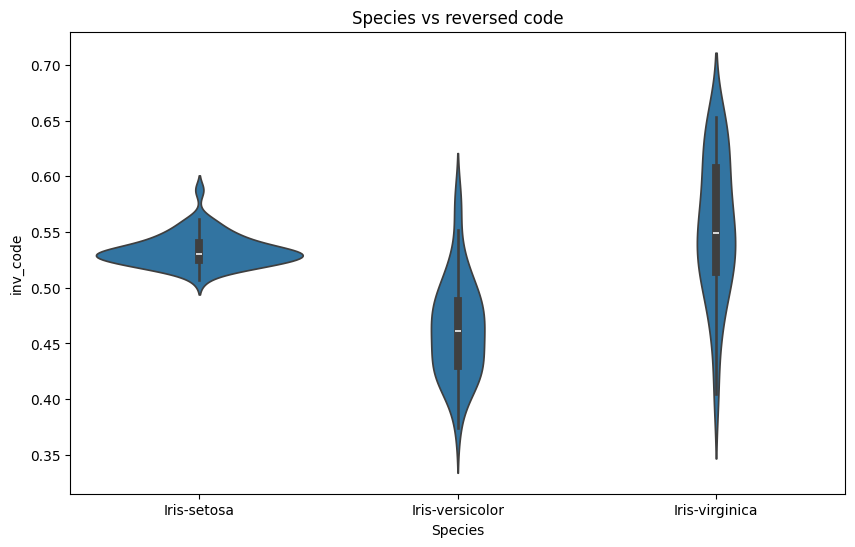

분류 정확도: 72.67%


In [15]:
rollback_trial("IRIS_InfoQGAN_sd0.8_nq4_nl30_Feb23_23_34_36", 226)

C:\Users\minkyu\AppData\Local\Temp\ipykernel_20700\4140398927.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  generator_initial_params = torch.load(f'{base_dir}/params/

(150, 6) Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')


100%|██████████| 150/150 [00:16<00:00,  8.94it/s]


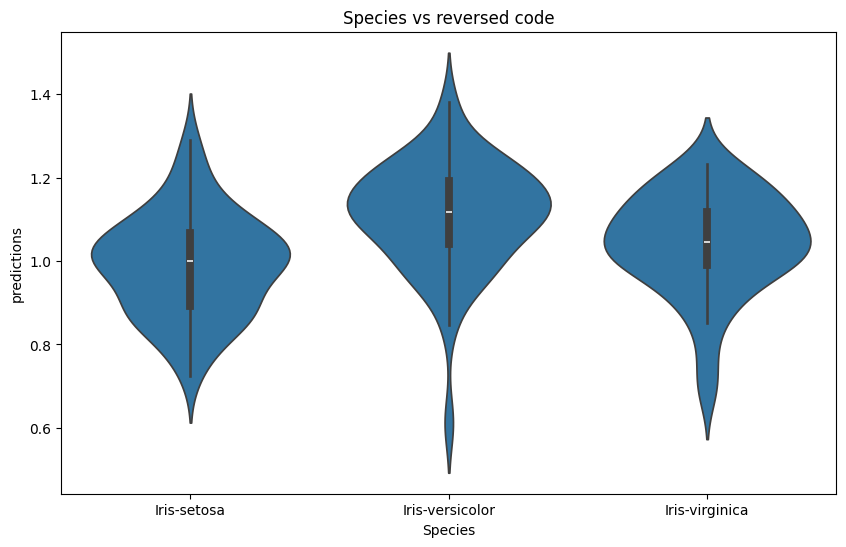

분류 정확도: 48.00%


In [16]:

def rollback_trial_ampl(trial_name:str, epoch:int):
    # args.txt 파일 경로 설정
    base_dir = f'./runs/{trial_name}'
    args_file_path = f'{base_dir}/args.txt'

    # args.txt 파일 읽기 및 파라미터 추출
    with open(args_file_path, 'r') as file:
        args = json.load(file)

    quantum_device = qml.device("lightning.qubit", wires=args['n_qubits'])
    generator_initial_params = torch.load(f'{base_dir}/params/generator_params_epoch{epoch}.pth').detach()

    generator = QGAN.QGAN2_ampl(args['n_qubits'], args['n_qubits'], args['n_layers'], -generator_initial_params, quantum_device) # 파라미터 부호 뒤집어서 넣는다.

    path = kagglehub.dataset_download("uciml/iris")
    csv_file = os.path.join(path, "iris.csv")
    raw_data_df = pd.read_csv(csv_file)
    data_num = len(raw_data_df)

    # 데이터 전처리
    # 수치형 변수 선택
    numeric_cols = raw_data_df.select_dtypes(include=['float64', 'int64']).columns.tolist()
    print(raw_data_df.shape, raw_data_df.columns)
    train_data_df = raw_data_df[numeric_cols]
    train_data_df = train_data_df.drop(columns=['Id'])
    train_data_np = train_data_df.to_numpy()

    # 학습 데이터셋을 [range_l, range_r] 범위로 rescale

    train_data_np = train_data_df.to_numpy()
    min_val = train_data_np.min(axis=0)
    max_val = train_data_np.max(axis=0)

    # range_l ~ range_r 범위로 rescale
    rescaled = args['range_l'] + (train_data_np - min_val) / (max_val - min_val) * (args['range_r'] - args['range_l'])
    train_tensor = torch.tensor(rescaled, dtype=torch.float32) # 학습에 사용할 텐서 (|1> 기준)

    predictions = np.zeros(data_num)
    for i in tqdm(range(data_num)):
        generator_seed = generate_samples(7, args['n_qubits'], train_tensor[i].numpy())
        generator_seed = np.sqrt(generator_seed) # ampl imbedding 을 위해 제곱근 취함
        generator_seed = torch.tensor(generator_seed, dtype=torch.float32)
        generator_output = generator.forward(generator_seed)
        generator_output = output_postprocessing(generator_output) # (BATCH_SIZE, n_qubits), |1> 기준 확률

        inv_seed = 2 * torch.asin(torch.sqrt(generator_output)) * 2 / np.pi
        inv_seed = inv_seed.detach().numpy()
        inv_code = inv_seed[:, 0].reshape(-1)


        # get median
        predictions[i] = np.median(inv_code)


    df = pd.DataFrame({'predictions': predictions, 'Species': raw_data_df['Species']})

    # Seaborn의 violinplot을 사용하여 Species별 inv_code 분포 시각화
    plt.figure(figsize=(10, 6))
    sns.violinplot(x='Species', y='predictions', data=df)
    plt.title('Species vs reversed code')
    plt.xlabel('Species')
    plt.ylabel('predictions')
    plt.show()

    species_means = df.groupby('Species')['predictions'].mean()

    # 각 데이터 포인트를 가장 가까운 중심값을 가진 Species로 분류
    def assign_species(prediction):
        # 각 Species 중심값과의 거리 계산
        distances = abs(species_means - prediction)
        # 가장 가까운 중심값을 가진 Species 반환
        return distances.idxmin()

    # 예측된 Species
    df['Predicted_Species'] = df['predictions'].apply(assign_species)

    # 분류 정확도 계산
    accuracy = (df['Species'] == df['Predicted_Species']).mean()
    print(f'분류 정확도: {accuracy * 100:.2f}%')

rollback_trial_ampl("IRIS_InfoQGAN_sd0.8_nq4_nl30_Feb23_23_34_36", 226)

In [10]:

# 예제 사용: d=2, 각 큐빗의 1 확률이 [0.3, 0.5]일 때
if __name__ == '__main__':
    d = 2
    p = np.array([0.3, 0.4])  # p[0]: 첫번째 큐빗, p[1]: 두번째 큐빗
    n = 5  # 5개의 샘플 생성
    samples = generate_samples(n, d, p)
    print(samples.shape)
    print(samples.shape)
    for vec in samples:
        print(np.round(vec, 5), "합:", np.sum(vec))

(5, 4)
(5, 4)
[0.44617 0.15383 0.25383 0.14617] 합: 0.9999999999999993
[0.41633 0.18367 0.28367 0.11633] 합: 0.9999999999999993
[0.37589 0.22411 0.32411 0.07589] 합: 0.9999999999999993
[0.5215 0.0785 0.1785 0.2215] 합: 0.9999999999999991
[0.3817 0.2183 0.3183 0.0817] 합: 0.9999999999999992


In [59]:
import numpy as np
from scipy.linalg import null_space

def build_constraints(d, p):
    """
    d: 큐빗 수
    p: 길이 d인 각 큐빗의 1 확률 (p[0]은 첫번째 큐빗 등)
    
    반환:
      A: (d+1) x (2^d) 행렬, 첫 행은 전체합=1, 이후 각 행은 해당 큐빗의 1 확률 조건
      b: 조건 우변, b[0]=1, b[i+1]=p[i]
    """
    N = 2**d
    A = np.ones((d+1, N))
    for i in range(d):
        for j in range(N):
            # j의 이진표현에서 i번째 비트 (0이면 0, 1이면 1)
            A[i+1, j] = (j >> i) & 1
    b = np.concatenate(([1], p))
    return A, b

def product_state(d, p):
    """
    각 큐빗이 독립적인 곱상태 (product state)로 시작.
    각 기저상태의 확률은 ∏_{i} [p[i] if bit==1 else (1-p[i])]
    """
    N = 2**d
    x = np.zeros(N)
    for j in range(N):
        pr = 1.0
        for i in range(d):
            bit = (j >> i) & 1
            pr *= p[i] if bit else (1 - p[i])
        x[j] = pr
    return x

def hit_and_run_step(x, NS, tol=1e-12):
    """
    현재 점 x에서 null space(NS) 내 임의 방향을 따라
    hit-and-run 알고리즘 한 스텝 실행.
    x는 2^d 크기의 벡터, NS는 A의 null space basis (행렬)
    """
    k = NS.shape[1]
    coeff = np.random.randn(k)
    d_dir = NS.dot(coeff)
    norm = np.linalg.norm(d_dir)
    if norm < tol:
        return x  # 아주 작은 방향이면 그대로
    d_dir /= norm

    t_lower = -np.inf
    t_upper = np.inf
    # 모든 좌표 j에 대해, x[j] + t * d_dir[j] >= 0
    for j in range(len(x)):
        if abs(d_dir[j]) < tol:
            continue
        t_bound = - x[j] / d_dir[j]
        if d_dir[j] > 0:
            # t >= -x[j]/d_dir[j]
            t_lower = max(t_lower, -x[j] / d_dir[j])
        else:  # d_dir[j] < 0
            # t <= -x[j]/d_dir[j]
            t_upper = min(t_upper, -x[j] / d_dir[j])
    # 안전 검사: interior point이면 t_lower < t_upper
    if t_lower > t_upper:
        t_lower, t_upper = t_upper, t_lower
    t = np.random.uniform(t_lower, t_upper)
    return x + t * d_dir

def generate_samples(n, d, p, burn_in=100):
    """
    n: 생성할 샘플 수
    d: 큐빗 수
    p: 길이 d인 각 큐빗의 1 확률 벡터
    burn_in: 초기 burn-in 스텝 수
    반환:
       n x (2^d) 크기의 샘플 배열
    """
    N = 2**d
    A, b = build_constraints(d, p)
    # product state로 시작 (내부에 있음)
    x = product_state(d, p)
    # 제약조건 Ax=b를 만족하는 null space 계산
    NS = null_space(A)  # shape: (N, N-(d+1))
    
    # burn-in 단계
    for _ in range(burn_in):
        x = hit_and_run_step(x, NS)
    
    samples = []
    for _ in range(n):
        x = hit_and_run_step(x, NS)
        samples.append(x.copy())
    return np.array(samples)

# 예제 사용: d=2, 각 큐빗의 1 확률이 [0.3, 0.5]일 때
if __name__ == '__main__':
    d = 2
    p = np.array([0.3, 0.5])  # p[0]: 첫번째 큐빗, p[1]: 두번째 큐빗
    n = 5  # 5개의 샘플 생성
    samples = generate_samples(n, d, p)
    for vec in samples:
        print(np.round(vec, 3), "합:", np.sum(vec))

[0.274 0.226 0.426 0.074] 합: 0.9999999999999998
[0.332 0.168 0.368 0.132] 합: 0.9999999999999997
[0.386 0.114 0.314 0.186] 합: 0.9999999999999997
[0.246 0.254 0.454 0.046] 합: 0.9999999999999997
[0.358 0.142 0.342 0.158] 합: 0.9999999999999997


In [38]:
mask = (torch.arange(4) >> 1) & 1
1-mask

tensor([1, 1, 0, 0])